ANALISI ESPLORATIVA

In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from pydub import AudioSegment
from pathlib import Path
from datetime import datetime
import traceback
from scipy.signal import butter, sosfilt
import soundfile as sf
import pandas as pd
import os
import matplotlib.dates as mdates
import sys
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
np.set_printoptions(threshold=sys.maxsize)

# --- CONFIGURAZIONE PERCORSI ---
INPUT_DIR_EXPLORATION = Path("AudioSamplesExploration")
INPUT_DIR_FILTERED = Path("AudioSamplesFiltered")
PREPROCESSED_DIR = Path("AudioSamplesExplorationPreprocessed")
WAVE_DIR = Path("WaveformsExploration")
SPECTRO_DIR = Path("SpectrogramsExploration")
DISTRIBUTION_DIR = Path("Distributions")
DISTRIBUTION_NORMALIZED_DIR = Path("Distributions/NormalizedAudio")
DISTRIBUTION_NOT_NORMALIZED_DIR = Path("Distributions/NotNormalizedAudio")

# --- CONFIGURAZIONE RANGE ---
RANGES = {
    "mattina":("06:00", "12:00"),
    "pomeriggio": ("12:00", "19:00"),
    "sera": ("19:00", "23:59"),
    "notte": ("00:00", "06:00")
}
SAMPLE_RATE = 16000
FRAME_SIZE = 2048
HOP_LENGTH = 512
TARGET_DB = -1.0
target_amplitude = librosa.db_to_amplitude(TARGET_DB)
CUTOFF_FREQ = 100

def to_minutes(time_str):
    h, m = map(int, time_str.split(':'))
    return h * 60 + m

MINUTI_RANGES = {k: (to_minutes(v[0]), to_minutes(v[1])) for k, v in RANGES.items()}

DATE_FORMAT = "%Y-%m-%dT%H:%M:%S%z"
TITLE_DATE_FORMAT = "%d-%m-%Y, %H:%M:%S"

# Creazione automatica delle cartelle
for d in [WAVE_DIR, SPECTRO_DIR, PREPROCESSED_DIR, DISTRIBUTION_DIR, DISTRIBUTION_NORMALIZED_DIR, DISTRIBUTION_NOT_NORMALIZED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

for fascia in RANGES.keys():
    # Creiamo le sottocartelle anche per i pre-processed
    for base in [WAVE_DIR, SPECTRO_DIR, PREPROCESSED_DIR]:
        (base / fascia).mkdir(parents=True, exist_ok=True)

In [ ]:
def highpass_filter(data, cutoff, sr, order=5):
    # Nyquist frequency è la metà della frequenza di campionamento
    nyq = 0.5 * sr
    normal_cutoff = cutoff / nyq
    
    # Crea il filtro in formato SOS (Second-Order Sections) 
    # È più stabile numericamente rispetto al formato classico
    sos = butter(order, normal_cutoff, btype='high', analog=False, output='sos')
    
    # Applica il filtro
    filtered_data = sosfilt(sos, data)
    return filtered_data

def preprocess(audio, offset_to_cut=0.5, normalize=False):
    # 1. TAGLIO
    offset = int(offset_to_cut * SAMPLE_RATE)
    audio = audio[offset:-offset]
    
    # 2. FILTRO E (opzionale) NORMALIZZAZIONE 
    audio = audio - np.mean(audio)
    audio = highpass_filter(audio, cutoff=CUTOFF_FREQ, sr=SAMPLE_RATE, order=8)
    if normalize:
        audio = librosa.util.normalize(audio) * target_amplitude
    return audio

In [4]:
def explore(filename, timestamp_dt):
    try:
        
        # 1. ESTRAZIONE TIMESTAMP
        timestamp_str_title = timestamp_dt.strftime(TITLE_DATE_FORMAT)
        timestamp_str=timestamp_dt.strftime(DATE_FORMAT).replace(":", "-")[:-5]
        minuti_file = timestamp_dt.hour * 60 + timestamp_dt.minute
        
        fascia = "notte"
        for f, (inizio, fine) in MINUTI_RANGES.items():
            if inizio <= minuti_file < fine:
                fascia = f
                break

        # 2. CARICAMENTO E TAGLIO
        #audio = AudioSegment.from_wav(file_src)
        filepath = INPUT_DIR_EXPLORATION / filename
        audio, sr = librosa.load(filepath, sr=SAMPLE_RATE)
        audio=preprocess(audio, offset_to_cut=0.5, normalize=True)

        # 4. SALVATAGGIO E LETTURA PER GRAFICI
        out_file_path = PREPROCESSED_DIR / fascia / f"preprocessed_audio_{timestamp_str}.wav"
        #audio_normalized.export(out_file_path, format="wav")
        sf.write(out_file_path, audio, SAMPLE_RATE)

        # --- GENERAZIONE GRAFICI ---
        # Waveform
        plt.figure(figsize=(10, 3))
        librosa.display.waveshow(audio, sr=SAMPLE_RATE, color="steelblue")
        plt.title(f"Waveform ({fascia}): {timestamp_str_title}")
        plt.tight_layout()
        plt.savefig(WAVE_DIR / fascia / f"waveform_{timestamp_str}.png")
        plt.close()

        # Spettrogramma
        plt.figure(figsize=(10, 4))
        S = librosa.feature.melspectrogram(y=audio, sr=SAMPLE_RATE, n_fft=FRAME_SIZE, hop_length=HOP_LENGTH, window='hann')
        S_dB = librosa.power_to_db(S, ref=np.max)
        img = librosa.display.specshow(S_dB, sr=SAMPLE_RATE, x_axis='time', y_axis='mel', cmap='magma')
        plt.colorbar(img, format='%+2.0f dB')
        plt.title(f"Mel-Spectrogram ({timestamp_str_title})")
        plt.tight_layout()
        plt.savefig(SPECTRO_DIR / fascia / f"spectrogram_{timestamp_str}.png")
        plt.close()

        print(f"Elaborato, salvato e smistato in {fascia}: {filename}")
    except Exception as e:
        traceback.print_exception(type(e), e, e.__traceback__)
        print(f"Errore su {filename}: {e}")

In [5]:
audio_df = pd.read_csv('audio_samples_metadata.csv')

'''
files_in_folder = set(os.listdir("AudioSamplesExploration"))

for row in audio_df.itertuples():
    if row.filename in files_in_folder:
        timestamp=row.timestamp.replace(" ","T")
        timestamp_dt = datetime.strptime(timestamp, DATE_FORMAT)
        explore(row.filename, timestamp_dt)
    
print("Elaborazione completata.")
'''

'\nfiles_in_folder = set(os.listdir("AudioSamplesExploration"))\n\nfor row in audio_df.itertuples():\n    if row.filename in files_in_folder:\n        timestamp=row.timestamp.replace(" ","T")\n        timestamp_dt = datetime.strptime(timestamp, DATE_FORMAT)\n        explore(row.filename, timestamp_dt)\n\nprint("Elaborazione completata.")\n'

In [6]:
def get_audio_energy_selected_frequencies(filepath, ranges_hz, normalize=False):
    """
    Carica, processa e calcola l'energia media nelle bande Hz specificate.
    ranges_hz: lista di tuple, es. [(100, 500), (2000, 4000)]
    """
    # 1. CARICAMENTO
    audio, sr = librosa.load(filepath, sr=SAMPLE_RATE)
    
    audio=preprocess(audio, offset_to_cut=0.5, normalize=normalize)
    
    # 4. SPETTROGRAMMA (Ampiezza)
    # n_fft e hop_length definiscono la risoluzione. 
    # Con n_fft=2048 a 22050Hz, ogni bin è circa 10.7 Hz
    S = np.abs(librosa.stft(y=audio, n_fft=FRAME_SIZE, hop_length=HOP_LENGTH, window='hann'))
    freqs = librosa.fft_frequencies(sr=SAMPLE_RATE, n_fft=FRAME_SIZE)
    
    # 5. ESTRAZIONE ENERGIA DAI RANGE DEFINITI
    total_energy_values = []
    
    for f_min, f_max in ranges_hz:
        # Trovo gli indici per questo specifico range
        idx = np.where((freqs >= f_min) & (freqs <= f_max))[0]
        if len(idx) > 0:
            # Media dell'energia in questa banda (su frequenze e tempo)
            band_energy = np.median(S[idx, :])
            total_energy_values.append(band_energy)
    
    # Faccio la media delle energie delle bande selezionate
    # (Se vuoi l'energia totale, potresti usare np.sum)
    final_energy = np.median(total_energy_values) if total_energy_values else 0
    
    return final_energy

In [7]:
# RANGE: 1400-3000, 4000-5000, 6500-8000 Hz
# RANGE (2): 1400-2200, 4000-6500
# RANGE (3): 1400-4500
ranges_hz = [(1400, 5000)]

audio_graphic_df= audio_df.copy()
audio_graphic_df['timestamp'] = pd.to_datetime(audio_graphic_df['timestamp'])
# Calcolo dell'energia per ogni riga
audio_graphic_df['energy_with_normalized_audio'] = audio_graphic_df['filename'].apply(
    lambda x: get_audio_energy_selected_frequencies(INPUT_DIR_FILTERED / x, ranges_hz, normalize=True)
    )
audio_graphic_df['energy_without_normalized_audio'] = audio_graphic_df['filename'].apply(
    lambda x: get_audio_energy_selected_frequencies(INPUT_DIR_FILTERED / x, ranges_hz, normalize=False)
    )

audio_graphic_df['hour_decimal'] = (audio_graphic_df['timestamp'].dt.hour + 
                        audio_graphic_df['timestamp'].dt.minute / 60 + 
                        audio_graphic_df['timestamp'].dt.second / 3600)


audio_graphic_df['date'] = audio_graphic_df['timestamp'].dt.date
audio_graphic_df['day_name'] = audio_graphic_df['timestamp'].dt.day_name()
giorni_ita = {
    'Monday': 'Lunedì', 'Tuesday': 'Martedì', 'Wednesday': 'Mercoledì',
    'Thursday': 'Giovedì', 'Friday': 'Venerdì', 'Saturday': 'Sabato', 'Sunday': 'Domenica'
}
audio_graphic_df['day_it'] = audio_graphic_df['day_name'].map(giorni_ita)

# Ordina per tempo (fondamentale per il grafico)
audio_graphic_df = audio_graphic_df.sort_values('hour_decimal')

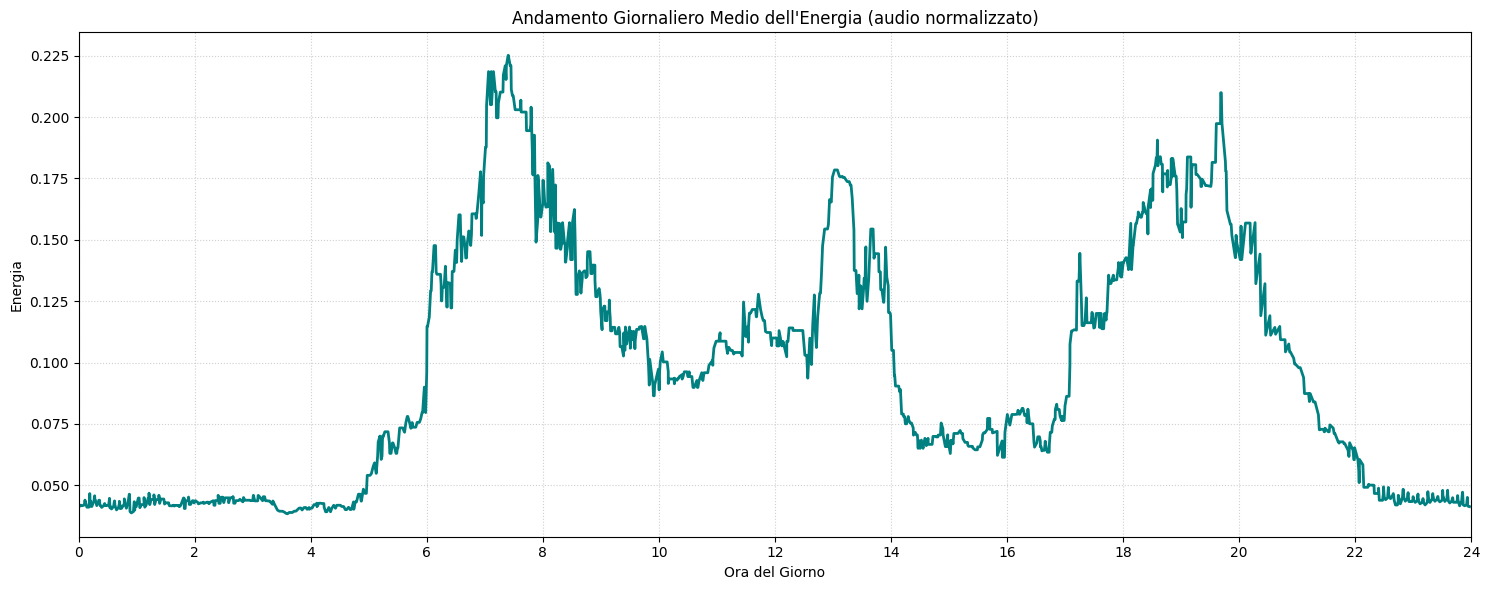

In [8]:
# Calcola la mediana mobile per "pulire" la linea
audio_graphic_df['energy_trend_with_normalized_audio'] = audio_graphic_df['energy_with_normalized_audio'].rolling(window=10, center=True, min_periods=1).median()

plt.figure(figsize=(15, 6))

# Plot della sola linea
plt.plot(audio_graphic_df['hour_decimal'], audio_graphic_df['energy_trend_with_normalized_audio'], color='teal', linewidth=2)

# Estetica e limiti
plt.xlim(0, 24)
plt.xticks(range(0, 25, 2))
plt.grid(True, linestyle=':', alpha=0.6)
plt.title('Andamento Giornaliero Medio dell\'Energia (audio normalizzato)')
plt.xlabel('Ora del Giorno')
plt.ylabel('Energia')

plt.tight_layout()
plt.show()

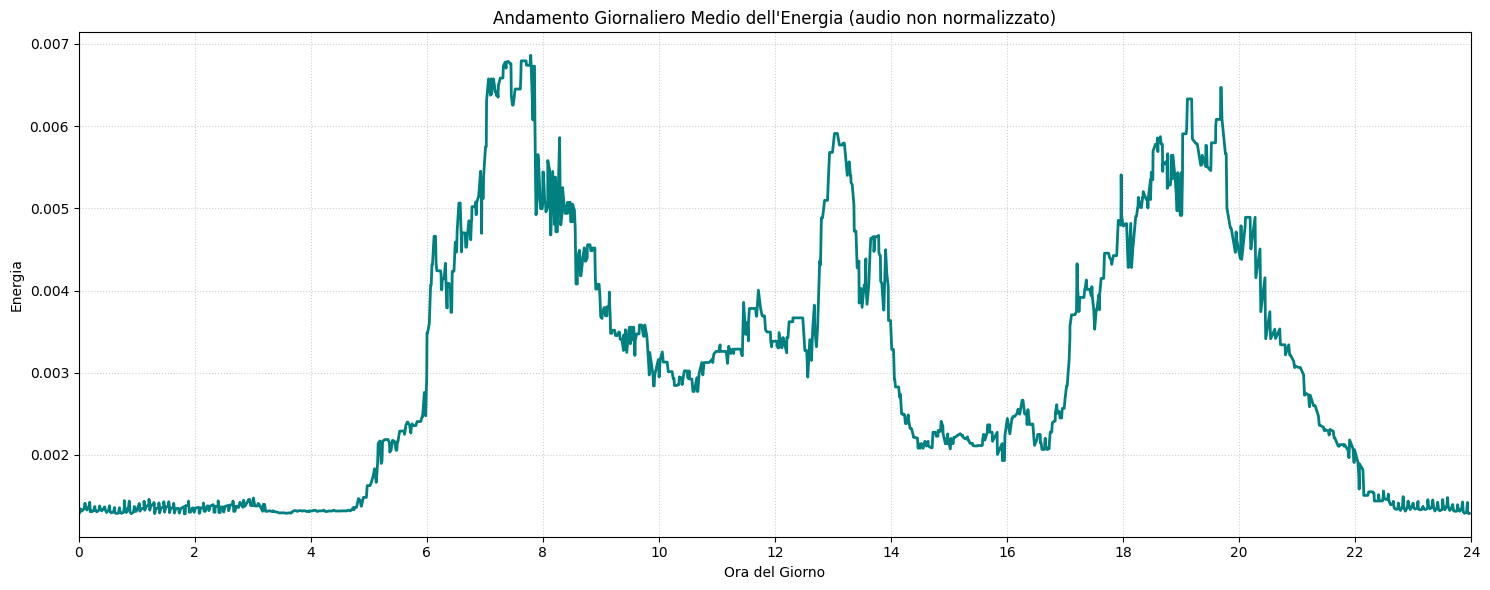

In [9]:
# Calcola la mediana mobile per "pulire" la linea
audio_graphic_df['energy_trend_without_normalized_audio'] = audio_graphic_df['energy_without_normalized_audio'].rolling(window=10, center=True, min_periods=1).median()

plt.figure(figsize=(15, 6))

# Plot della sola linea
plt.plot(audio_graphic_df['hour_decimal'], audio_graphic_df['energy_trend_without_normalized_audio'], color='teal', linewidth=2)

# Estetica e limiti
plt.xlim(0, 24)
plt.xticks(range(0, 25, 2))
plt.grid(True, linestyle=':', alpha=0.6)
plt.title('Andamento Giornaliero Medio dell\'Energia (audio non normalizzato)')
plt.xlabel('Ora del Giorno')
plt.ylabel('Energia')

plt.tight_layout()
plt.show()

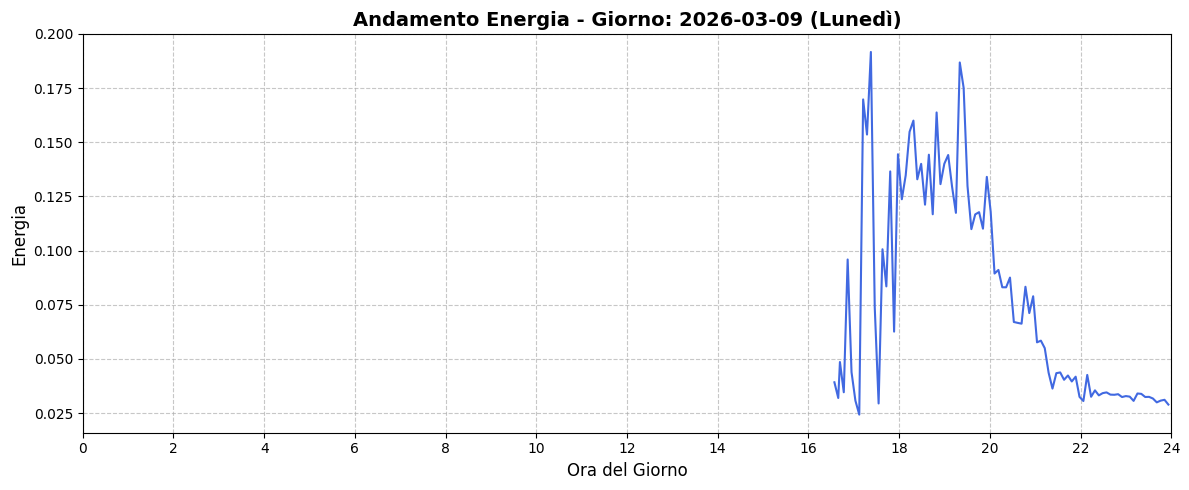

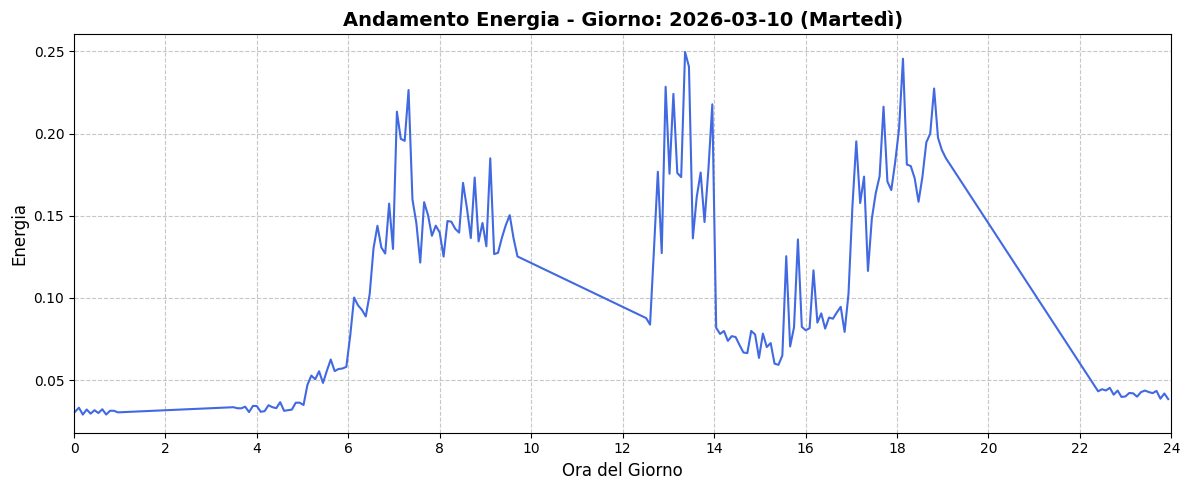

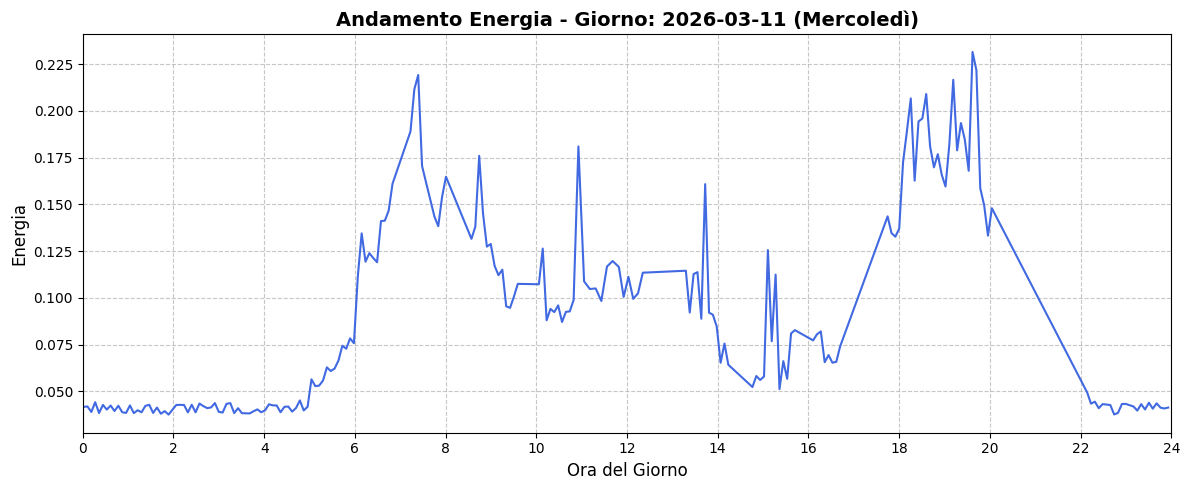

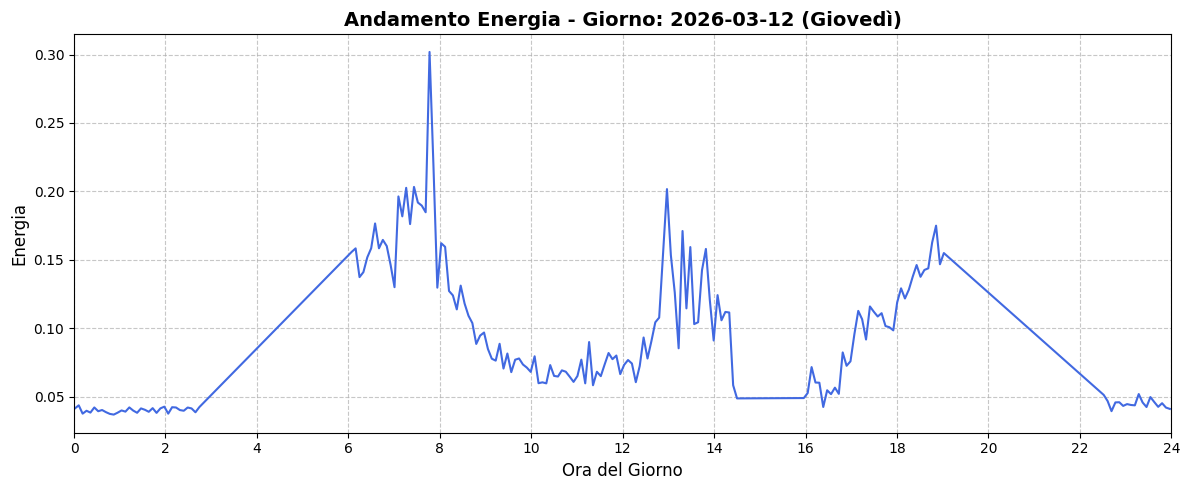

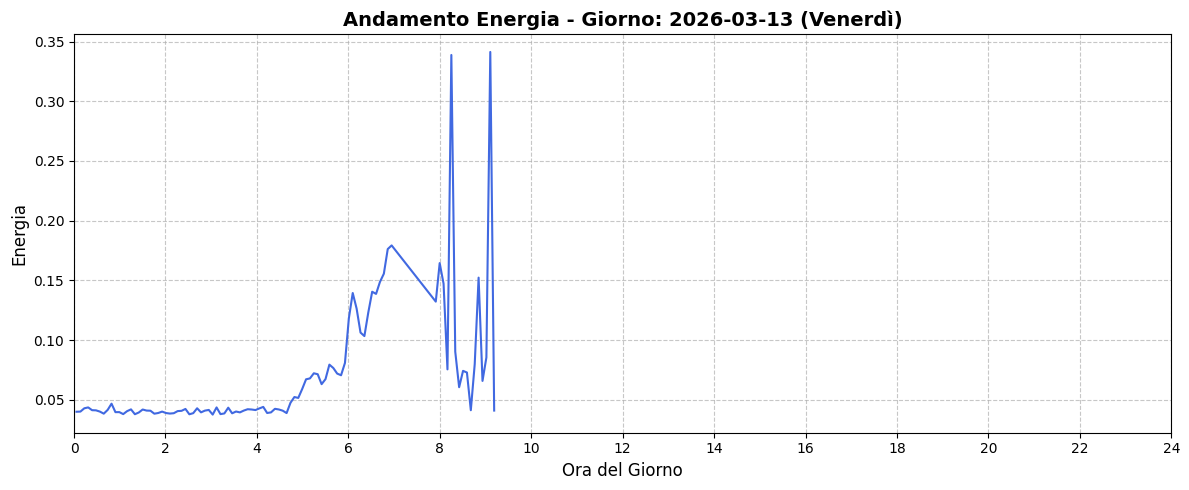

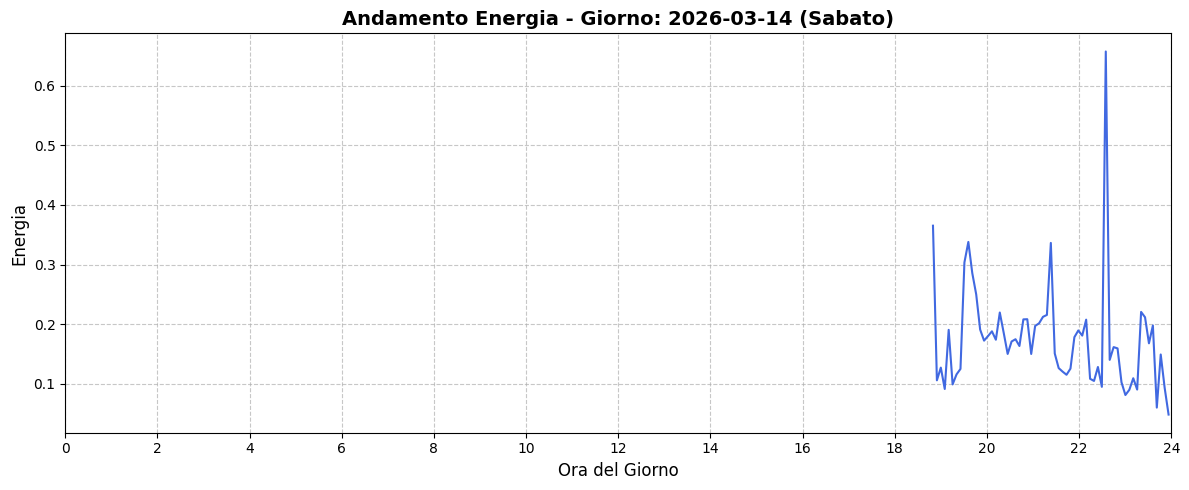

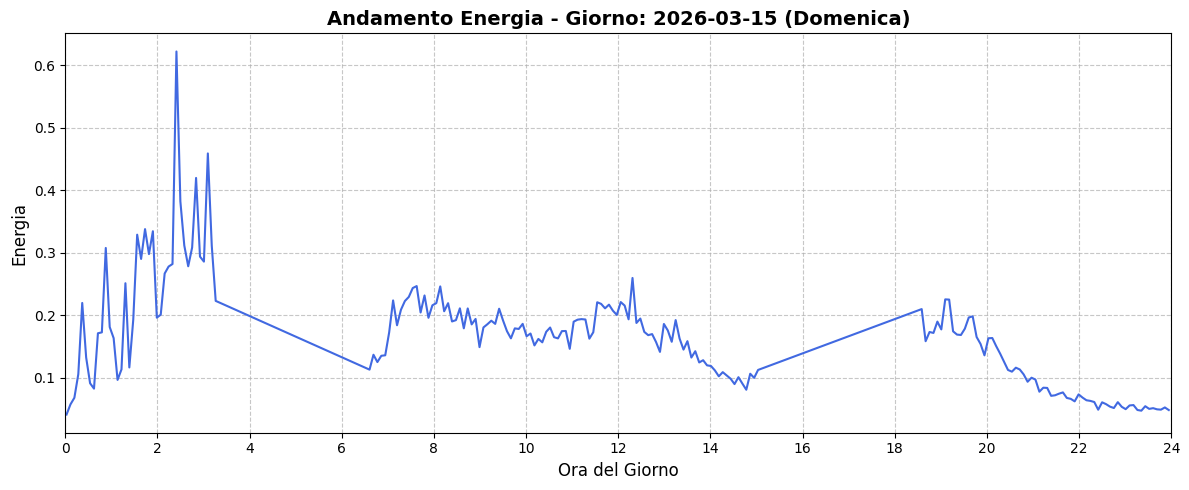

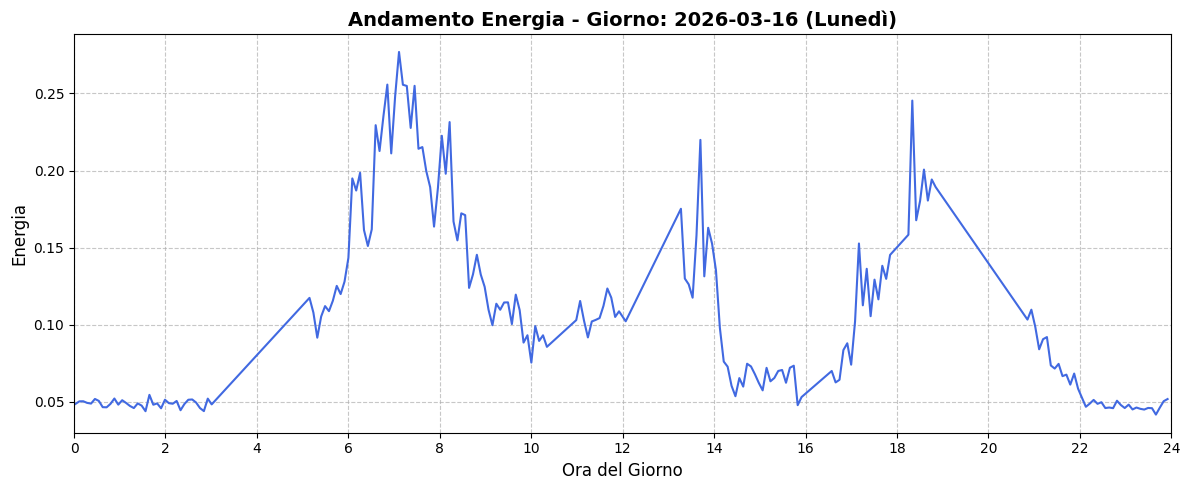

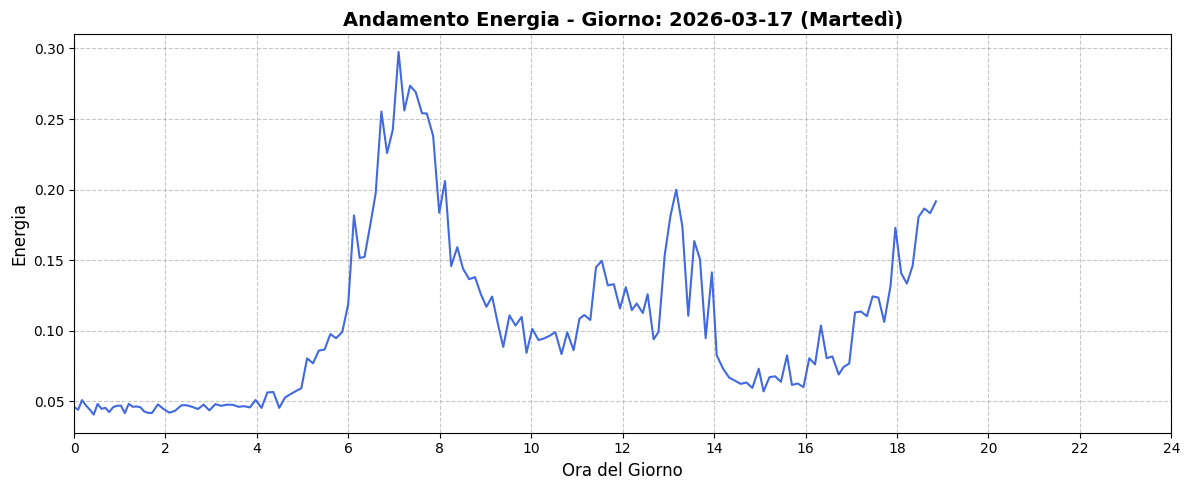

In [10]:
# Ciclo per generare un grafico per ogni giorno
for day, group in audio_graphic_df.groupby('date'):
    plt.figure(figsize=(12, 5))

    giorno_settimana = group['day_it'].iloc[0]
    
    # Disegniamo l'energia (con una leggera sfumatura se vuoi vedere i punti)
    sns.lineplot(data=group, x='hour_decimal', y='energy_with_normalized_audio', 
                 color='royalblue', linewidth=1.5)
    
    # Configurazione estetica
    plt.title(f"Andamento Energia - Giorno: {day} ({giorno_settimana})", fontsize=14, fontweight='bold')
    plt.xlabel("Ora del Giorno", fontsize=12)
    plt.ylabel("Energia", fontsize=12)
    
    # Forza l'asse X a mostrare l'intera giornata
    plt.xlim(0, 24)
    plt.xticks(range(0, 25, 2)) # Un tick ogni 2 ore
    
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()

    plt.savefig(f"{DISTRIBUTION_NORMALIZED_DIR}/energia_{day}.png")
    
    # Mostra a schermo (se sei su Notebook)
    plt.show()
    
    # Chiudi la figura per liberare memoria
    plt.close()

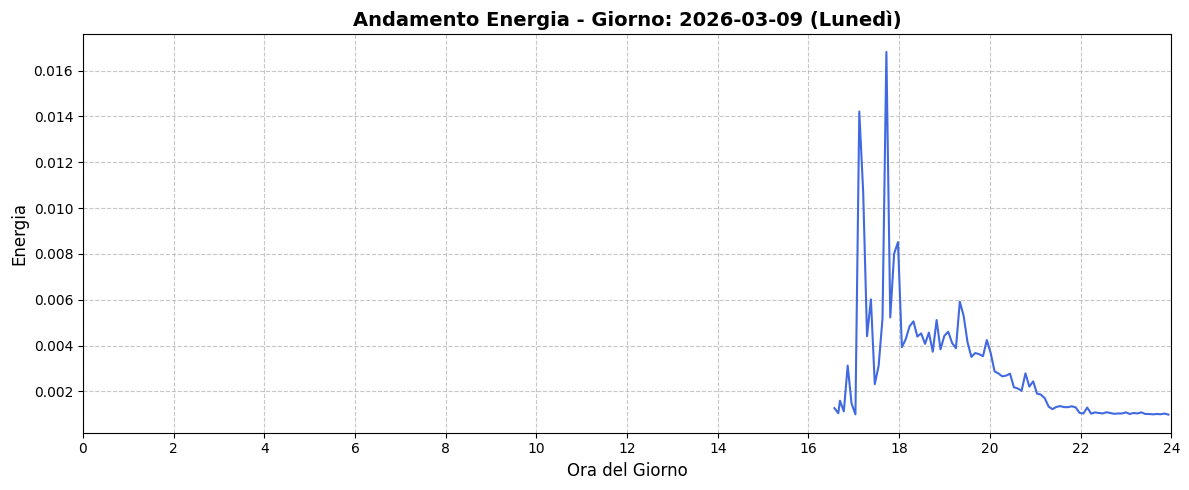

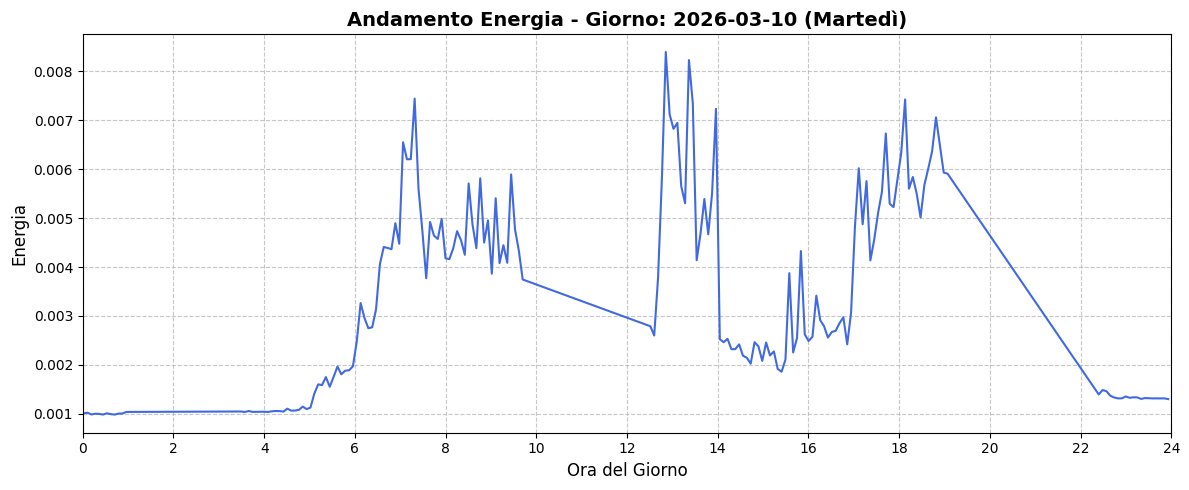

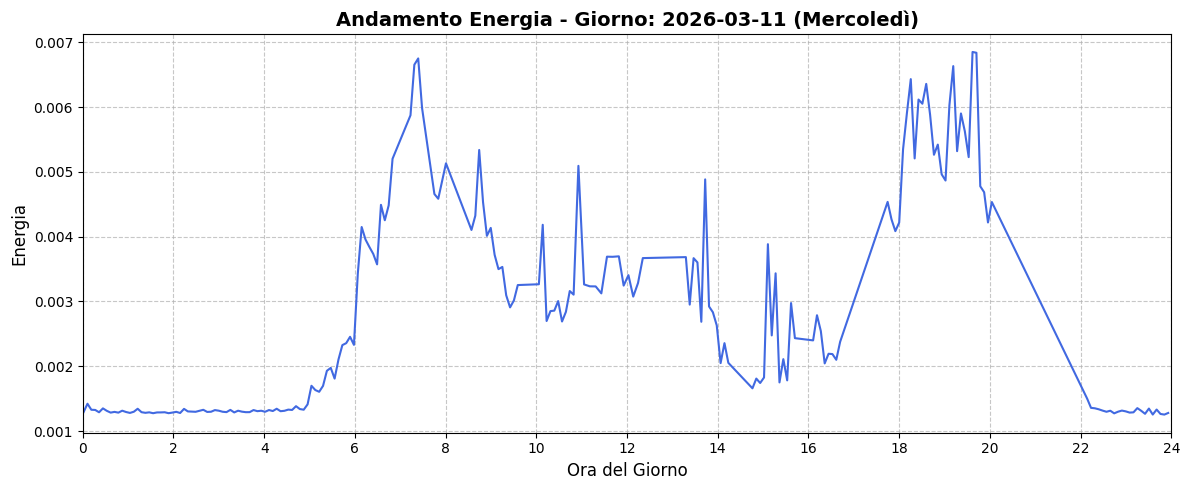

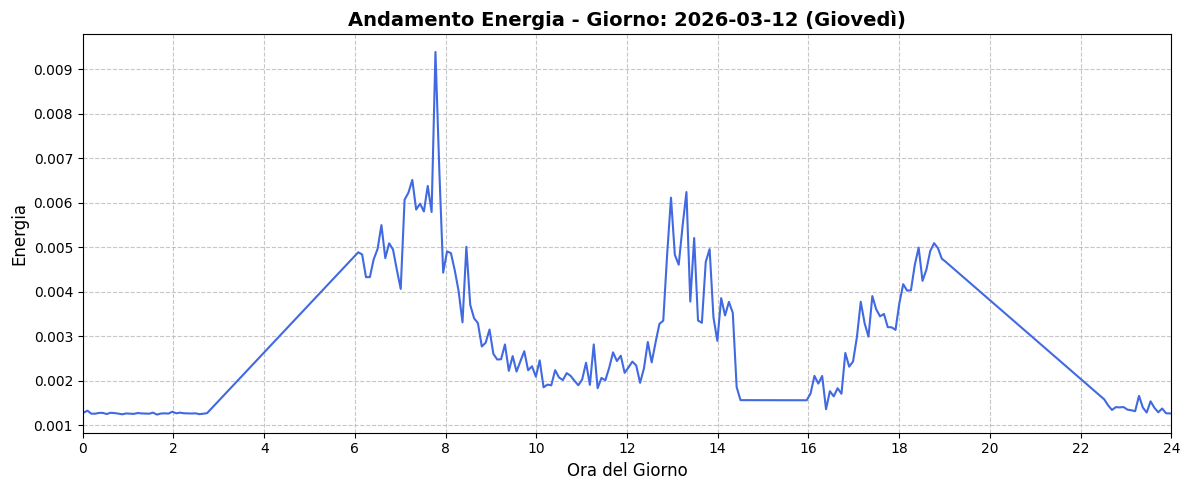

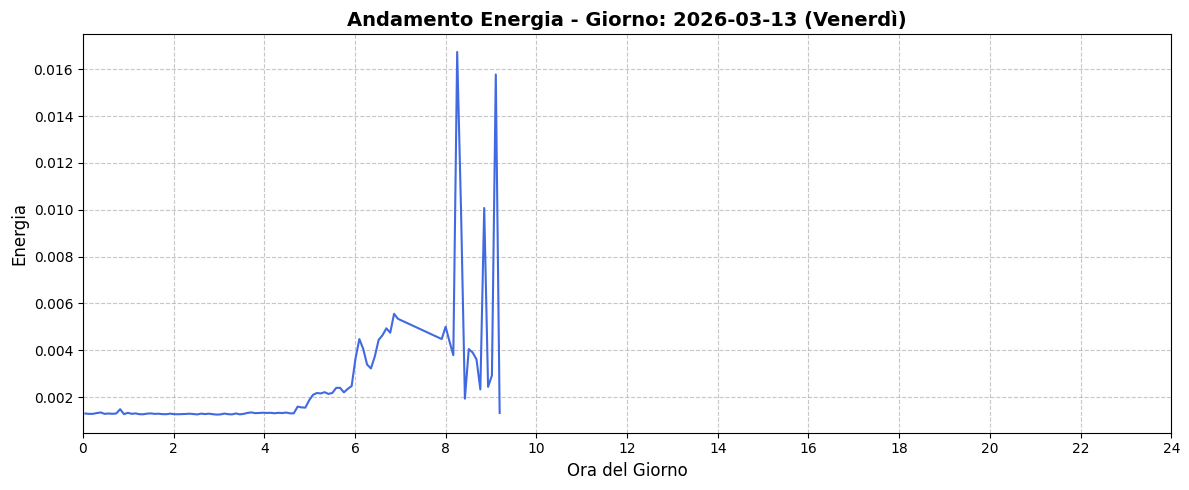

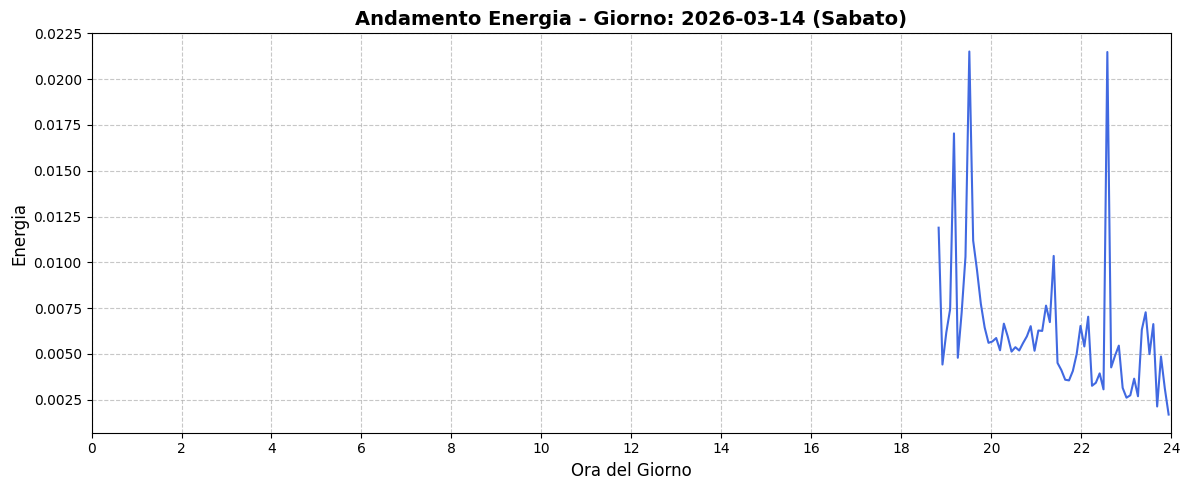

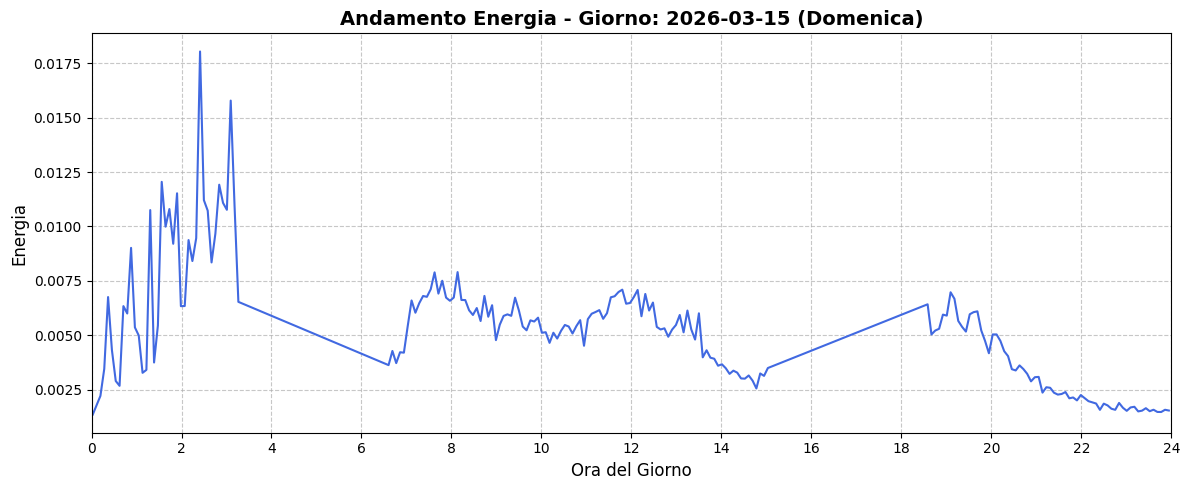

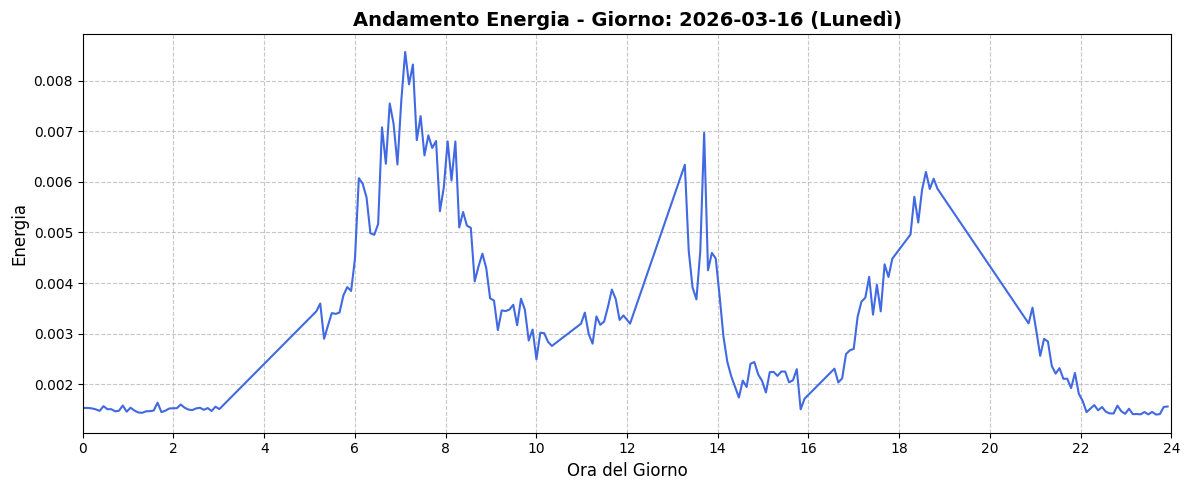

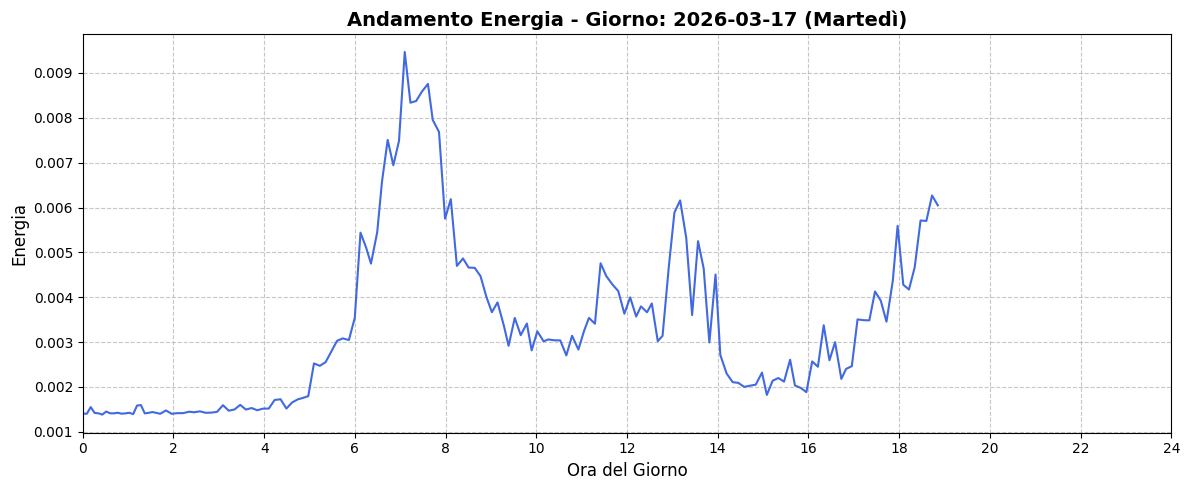

In [11]:
# Ciclo per generare un grafico per ogni giorno
for day, group in audio_graphic_df.groupby('date'):
    plt.figure(figsize=(12, 5))

    giorno_settimana = group['day_it'].iloc[0]
    
    # Disegniamo l'energia (con una leggera sfumatura se vuoi vedere i punti)
    sns.lineplot(data=group, x='hour_decimal', y='energy_without_normalized_audio', 
                 color='royalblue', linewidth=1.5)
    
    # Configurazione estetica
    plt.title(f"Andamento Energia - Giorno: {day} ({giorno_settimana})", fontsize=14, fontweight='bold')
    plt.xlabel("Ora del Giorno", fontsize=12)
    plt.ylabel("Energia", fontsize=12)
    
    # Forza l'asse X a mostrare l'intera giornata
    plt.xlim(0, 24)
    plt.xticks(range(0, 25, 2)) # Un tick ogni 2 ore
    
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()

    plt.savefig(f"{DISTRIBUTION_NOT_NORMALIZED_DIR}/energia_{day}.png")
    
    # Mostra a schermo (se sei su Notebook)
    plt.show()
    
    # Chiudi la figura per liberare memoria
    plt.close()